In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(r"C:\Users\eunsu\학교\2026-2\euron\DL_주차별_활동자료\3주차_5장\colab_5장.ipynb", download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST(r"C:\Users\eunsu\학교\2026-2\euron\DL_주차별_활동자료\3주차_5장\colab_5장.ipynb", download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.54MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

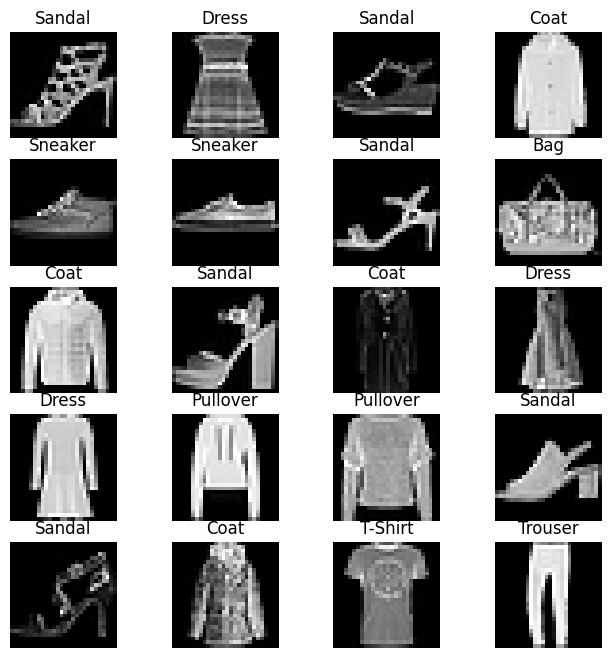

In [5]:
labels_map = {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8,8));
columns = 4;
rows = 5;
for i in range(1, columns*rows+1):
	img_xy = np.random.randint(len(train_dataset));
	img = train_dataset[img_xy][0][0, :, :]
	fig.add_subplot(rows, columns, i)
	plt.title(labels_map[train_dataset[img_xy][1]])
	plt.axis('off')
	plt.imshow(img, cmap = 'gray')
plt.show()

심층 신경망 생성 후 학습
(ConvNet)이 적용되지 않은 네트워크 만들기

In [6]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features = 256)
    self.drop= nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [7]:
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        label = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        # 50회 배치마다 검증 (train_loader 루프 안으로 이동)
        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        # 500회 배치마다 출력 (train_loader 루프 안으로 이동)
        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.632956862449646, Accuracy: 83.5999984741211
Iteration: 1000, Loss: 0.45012253522872925, Accuracy: 83.95999908447266
Iteration: 1500, Loss: 0.3562929034233093, Accuracy: 84.37999725341797
Iteration: 2000, Loss: 0.38690468668937683, Accuracy: 84.81999969482422
Iteration: 2500, Loss: 0.3093169927597046, Accuracy: 85.97999572753906
Iteration: 3000, Loss: 0.3006834387779236, Accuracy: 86.38999938964844


In [9]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size = 3, padding =1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features = 600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [10]:
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [12]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            model.eval()
            with torch.no_grad():
                for test_images, test_labels in test_loader:
                    test_images, test_labels = test_images.to(device), test_labels.to(device)
                    outputs = model(test_images)
                    predictions = torch.max(outputs, 1)[1]
                    correct += (predictions == test_labels).sum().item()
                    total += test_labels.size(0)

            accuracy = correct * 100 / total
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)
            model.train()

        if not (count % 500):
            print(f"Iteration: {count}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

Iteration: 500, Loss: 0.5401, Accuracy: 88.00%
Iteration: 1000, Loss: 0.3498, Accuracy: 89.14%
Iteration: 1500, Loss: 0.2487, Accuracy: 89.00%
Iteration: 2000, Loss: 0.1938, Accuracy: 89.30%
Iteration: 2500, Loss: 0.1362, Accuracy: 90.17%
Iteration: 3000, Loss: 0.1755, Accuracy: 90.70%


## 추가 설명 코드

In [18]:
import numpy as np

print("randint(10) -> 0 이상 10 미만의 정수 1개:")
print(np.random.randint(10))

print("\nrandint(1, 10) -> 1 이상 10 미만의 정수 1개:")
print(np.random.randint(1, 10))

print("\nrand(8) -> [0, 1) 균등분포 1D 배열 (길이 8):")
print(np.random.rand(8))

print("\nrand(4, 2) -> [0, 1) 균등분포 2D 배열 (4x2):")
print(np.random.rand(4, 2))

print("\nrandn(8) -> 표준정규분포 1D 배열 (길이 8):")
print(np.random.randn(8))

print("\nrandn(4, 2) -> 표준정규분포 2D 배열 (4x2):")
print(np.random.randn(4, 2))

randint(10) -> 0 이상 10 미만의 정수 1개:
6

randint(1, 10) -> 1 이상 10 미만의 정수 1개:
2

rand(8) -> [0, 1) 균등분포 1D 배열 (길이 8):
[0.59967122 0.82157997 0.12454949 0.59165164 0.31495853 0.60042294
 0.55087191 0.08152737]

rand(4, 2) -> [0, 1) 균등분포 2D 배열 (4x2):
[[0.65413112 0.15538709]
 [0.46559781 0.54135383]
 [0.58259254 0.23745814]
 [0.7254427  0.48021971]]

randn(8) -> 표준정규분포 1D 배열 (길이 8):
[ 1.09901942  1.10250234  1.3830409   0.1887834   1.50015269  1.11198755
  0.76113526 -1.12908065]

randn(4, 2) -> 표준정규분포 2D 배열 (4x2):
[[ 0.7067913   0.4352792 ]
 [-1.89546764  0.53231197]
 [-0.29595905 -0.19802294]
 [-1.19650883  0.10922937]]


In [17]:
import numpy as np

examp = np.arange(0, 72, 3).reshape(6, 4)

print("=== 2차원 배열 ===")
print("전체 배열:\n", examp)
print("3번째 행 (인덱스 3):", examp[3])
print("3행 3열 원소 (examp[3, 3]):", examp[3, 3])
print("3행 3열 원소 (examp[3][3]):", examp[3][3])


examp3d = np.arange(0, 225, 3).reshape(3, 5, 5)

print("\n=== 3차원 배열 ===")
print("전체 3차원 배열 형태:", examp3d.shape)
print("examp3d[2][0][3] 원소 값:", examp3d[2][0][3])

=== 2차원 배열 ===
전체 배열:
 [[ 0  3  6  9]
 [12 15 18 21]
 [24 27 30 33]
 [36 39 42 45]
 [48 51 54 57]
 [60 63 66 69]]
3번째 행 (인덱스 3): [36 39 42 45]
3행 3열 원소 (examp[3, 3]): 45
3행 3열 원소 (examp[3][3]): 45

=== 3차원 배열 ===
전체 3차원 배열 형태: (3, 5, 5)
examp3d[2][0][3] 원소 값: 159


클래스와 함수

In [16]:
def add(num1, num2):
  result = num1 + num2
  return result

print(add(1, 2))
print(add(2, 3))

3
5


In [19]:
class Calc:
  def __init__(self):
    self.result = 0

  def add(self, num1, num2):
    self.result = num1 + num2
    return self.result

obj1 = Calc()
obj2 = Calc()

print(obj1, add(1, 2))
print(obj1, add(2, 3))
print('----------------------------------------------------')
print(obj2, add(2, 2))
print(obj2, add(2, 3))

<__main__.Calc object at 0x7d187c492cf0> 3
<__main__.Calc object at 0x7d187c492cf0> 5
----------------------------------------------------
<__main__.Calc object at 0x7d1879d6d6d0> 4
<__main__.Calc object at 0x7d1879d6d6d0> 5


활성화 함수 사용 지정 방법
1. F.relu(): forward() 함수에서 정의
2. nn.ReLU(): __ init__() 함수에서 정의

In [20]:
#nn 사용 코드
import torch
import torch.nn as nn

inputs = torch.randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
outputs = conv(inputs)
layer = nn.Conv2d(1, 1, 3)

In [21]:
##nn.functional 사용 코드
import torch.nn.functional as F

inputs = torch.randn(64, 3, 244, 244)
weight = torch.randn(64, 3, 3, 3)
bias = torch.randn(64)
ouputs = F.conv2d(inputs, weight, bias, padding=1)